In [2]:
import sys
sys.path.append('../src')

import matplotlib.pyplot as plt
plt.style.core.USER_LIBRARY_PATHS.append('/gscratch/matsulab/utils/ctleelab-mpl-utilities/ctleelab_plothelper')
plt.style.reload_library()

In [14]:
from pinn.plot import visualize_phase

def plot_result(
    checkpoint_dir, 
    data_id,
    shape,
    steps_to_visualize=(0, 1000, 5000, 10000), 
    save_interval=100,
    axis = "x",
):

    # Decide which checkpoints to load (based on your save interval)
    max_step = max(steps_to_visualize)
    steps_series = list(range(0, max_step + 1, save_interval))

    # ---- Load checkpoints ----
    checkpoint_data = {}
    for step in steps_series:
        ckpt_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
        if os.path.exists(ckpt_path):
            checkpoint_data[step] = checkpoints.restore_checkpoint(ckpt_dir=ckpt_path, target=None)

    # Ensure the requested steps exist (otherwise plotting will crash / skip)
    steps_to_visualize = [s for s in steps_to_visualize if s in checkpoint_data]
    if len(steps_to_visualize) == 0:
        print(f"[plot_result] No checkpoints found in {checkpoint_dir}")
        return

    # ---- Load cryoET volume ----
    tif_file_path = f"../data/experimental/vol/formatted/{data_id}/{shape}.tif"
    cryoET_data = tiff.imread(tif_file_path)
    cryoET_data = 1 - cryoET_data
    grid_size = cryoET_data.shape[0]
    slice_index = grid_size // 2

    # ---- Make figure ----
    fig = plt.figure(figsize=(3 * 4, 12))

    # Row 1: CryoET + contours
    for i, step in enumerate(steps_to_visualize):
        ax = fig.add_subplot(4, 4, i + 1)
        visualize_cryoET_with_contours(
            ax, step, checkpoint_data[step], cryoET_data,
            grid_size=grid_size, slice_index=slice_index, axis=axis,
            thresholding=False
        )
        if i == 0:
            ax.set_ylabel("CryoET + Contours")

    # Row 2: phi
    for i, step in enumerate(steps_to_visualize):
        ax = fig.add_subplot(4, 4, 4 + i + 1)
        visualize_phase(
            ax, epsilon=0.05, checkpoint=checkpoint_data[step], component="phi",
            grid_size=grid_size, slice_index=slice_index, axis=axis,
            no_label=True, vmin=-1, vmax=1
        )
        if i == 0:
            ax.set_ylabel("Phi")

    # Row 3: tension
    for i, step in enumerate(steps_to_visualize):
        ax = fig.add_subplot(4, 4, 8 + i + 1)
        visualize_phase(
            ax, epsilon=0.05, checkpoint=checkpoint_data[step], component="tension",
            grid_size=grid_size, slice_index=slice_index, axis=axis,
            no_label=True, vmin=0.0, vmax=1.0
        )
        if i == 0:
            ax.set_ylabel("Tension energy")

    # Row 4: loss history
    assembled_loss = assemble_loss_history(checkpoint_data)
    ax = fig.add_subplot(4, 4, 12 + 1)
    plot_loss_history_ax(ax, assembled_loss)

    for i in [0, 1, 2]:
        ax = fig.add_subplot(4, 4, 12 + i + 2)
        j = 3 if i == 2 else i
        plot_normalized_loss_history_ax(ax, j, assembled_loss)

    plt.tight_layout()
    out_png = os.path.join(checkpoint_dir, "result.png")
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    # plt.show()
    print("Saved:", out_png)


/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/jrc_cos7-1b/bud-11/phase1_100000_1_100000_0
Saved: /mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/jrc_cos7-1b/bud-11/phase1_100000_1_100000_0/result.png


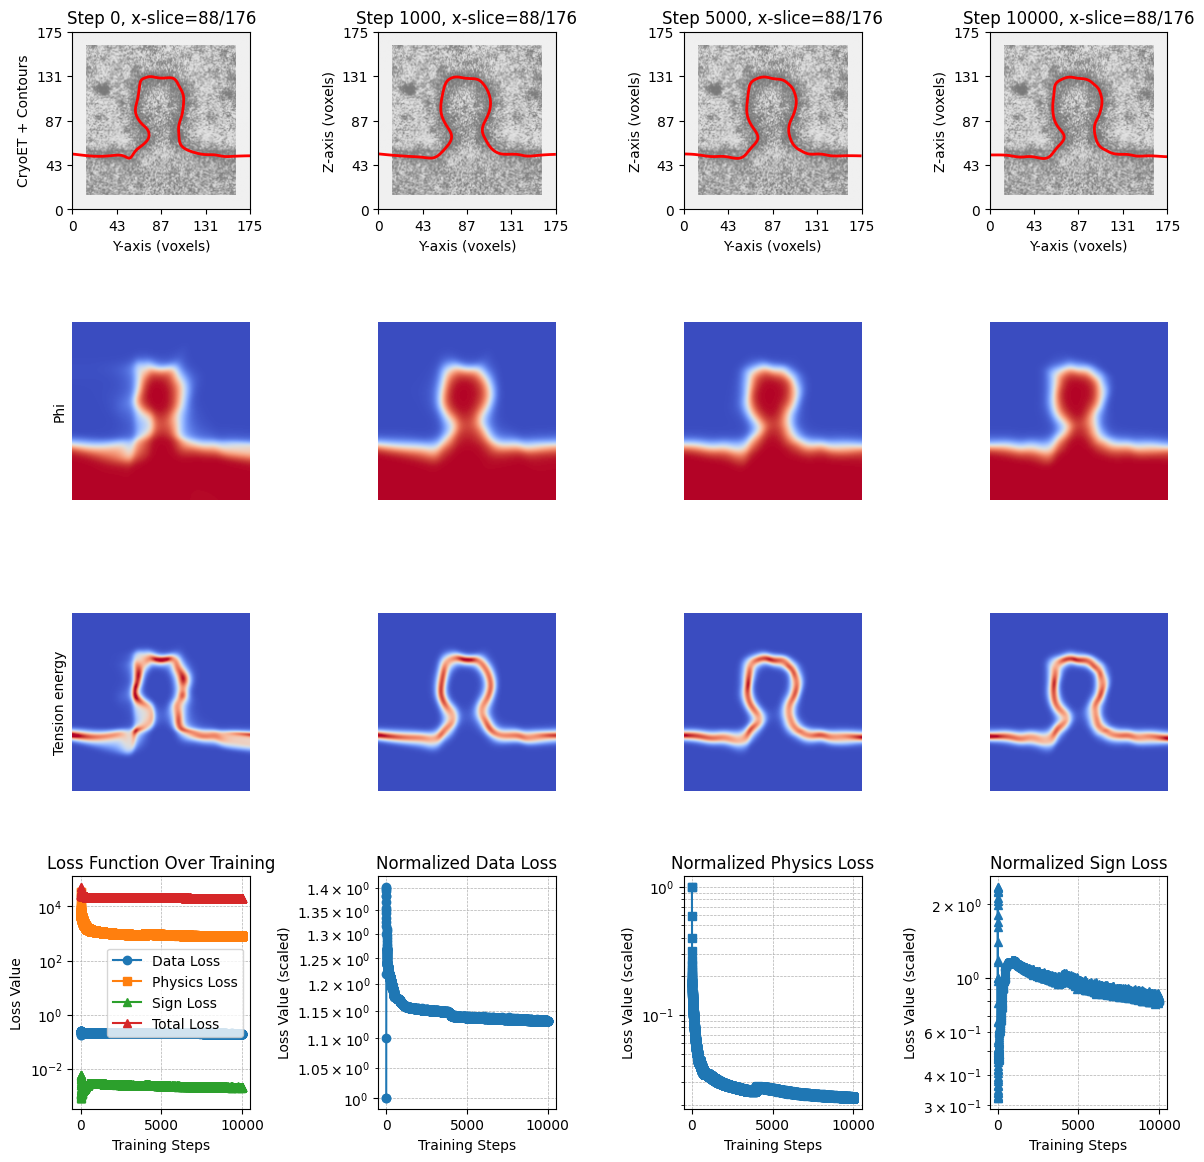

In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints

GRID_SIZE = 64
lambda_1 = 100000
lambda_2 = 1
lambda_3 = 100000
lambda_4 = 0
phase = 1
save_interval = 100

data_id = "jrc_cos7-1b"
shape = "bud-11"

steps_to_visualize = [0, 100, 1000, 10000]
steps_series = list(range(0, 10001, 100))

# Load checkpoint data
checkpoint_dir = os.path.abspath(f"../outputs/logs/{data_id}/{shape}/phase{phase}_{lambda_1}_{lambda_2}_{lambda_3}_{lambda_4}")
print(checkpoint_dir)

plot_result(
    checkpoint_dir=checkpoint_dir,
    data_id=data_id,
    shape=shape,
    steps_to_visualize=(0, 1000, 5000, 10000),
    save_interval=save_interval,
)

/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/outputs/logs/jrc_cos7-1b/bud-11/phase0_100000_0_100000_0


W0403 15:04:52.533238   26683 gemm_fusion_autotuner.cc:1053] Compiling 8 configs for 2 fusions on a single thread.
W0403 15:04:58.963421   26683 gemm_fusion_autotuner.cc:1050] Compiling 4 configs for gemm_fusion_dot_general.1 on a single thread.
W0403 15:04:59.507086   26683 gemm_fusion_autotuner.cc:1050] Compiling 9 configs for gemm_fusion_dot_general.1 on a single thread.
W0403 15:05:01.539676   26683 gemm_fusion_autotuner.cc:1050] Compiling 13 configs for gemm_fusion_dot.1 on a single thread.


ValueError: Surface level must be within volume data range.

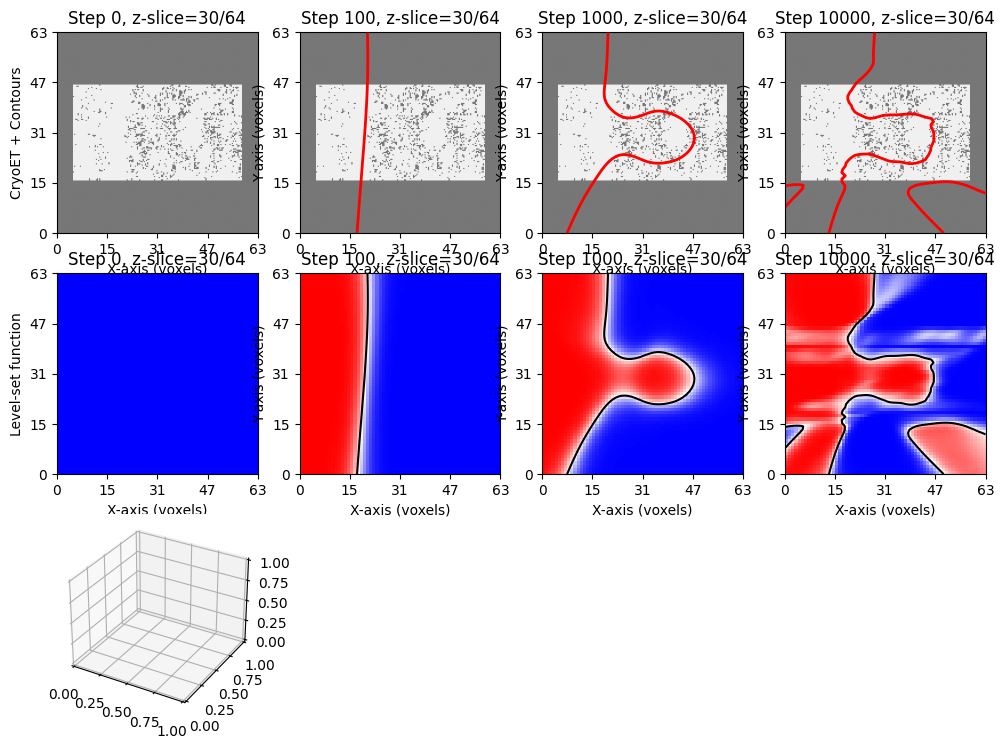

In [3]:
## make one combined image file

import os
import numpy as np
import matplotlib.pyplot as plt
import tifffile as tiff
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.model import PINN
from pinn.plot import (
    visualize_checkpoint_result,
    visualize_cryoET_with_contours,
    plot_3d_isosurface,
    plot_loss_history_ax,
    plot_normalized_loss_history_ax,
)
from pinn.utils import assemble_loss_history

GRID_SIZE = 64
lambda_1 = 100000
lambda_2 = 0
lambda_3 = 100000
lambda_4 = 0
phase = 0

data_id = "jrc_cos7-1b"
shape = "bud-11"

steps_to_visualize = [0, 100, 1000, 10000]
steps_series = list(range(0, 10001, 100))

# Load checkpoint data
checkpoint_dir = os.path.abspath(f"../outputs/logs/{data_id}/{shape}/phase{phase}_{lambda_1}_{lambda_2}_{lambda_3}_{lambda_4}")
print(checkpoint_dir)
checkpoint_data = {}
for step in steps_series:
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    checkpoint_data[step] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

# Load CryoET data
img_file_path = f"../data/experimental/vol/formatted/{data_id}/{shape}.tif" 
cryoET_data = tiff.imread(img_file_path)
# cryoET_data = load_mrc_data(img_file_path, grid_size=GRID_SIZE)

# Create a big figure with 4 rows: cryoET + contours, prediction result, 3D isosurface, and leave room for loss plots
fig = plt.figure(figsize=(3*4, 12))

# Row 1: visualize_cryoET_with_contours
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, i + 1)
    visualize_cryoET_with_contours(ax, step, checkpoint_data[step], cryoET_data, grid_size=GRID_SIZE, slice_index=30, axis="z", thresholding=True)
    if i == 0:
        ax.set_ylabel("CryoET + Contours")

# Row 2: visualize_checkpoint_result
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 4 + i + 1)
    visualize_checkpoint_result(ax, step, checkpoint_data[step], grid_size=GRID_SIZE, slice_index=30, axis="z")
    if i == 0:
        ax.set_ylabel("Level-set function")

# Row 3: plot_3d_isosurface
for i, step in enumerate(steps_to_visualize):
    ax = fig.add_subplot(4, 4, 8 + i + 1, projection='3d')
    plot_3d_isosurface(ax, step, checkpoint_data[step], grid_size=GRID_SIZE)
    if i == 0:
        ax.set_zlabel("3D Isosurface", rotation=180)

# Row 4: loss history
# plt.style.reload_library()
# with plt.style.context(["base", "transparent"]):
assembled_loss = assemble_loss_history(checkpoint_data)
ax = fig.add_subplot(4, 4, 12+1)
plot_loss_history_ax(ax, assembled_loss)
for i in [0,1,2]:
    ax = fig.add_subplot(4, 4, 12+i+2)
    plot_normalized_loss_history_ax(ax, i, assembled_loss)
    

info_text = (
    f"GRID_SIZE = {GRID_SIZE}, mask_thre = 0.8\n"
    f"num_layers = {num_layers}, hidden_dim = 16, num_freq = 10, learning_rate = 1e-3\n"
    f"lambda_data = {lambda_1:.1e}, lambda_physics = {lambda_2:.1e}\n"
    f"epsilon = 0.05, num_collocation = {num_collocation}"
)

fig.text(
    0.02, 1.08,  # (x, y) position in figure coordinates
    info_text,
    fontsize=12,
    ha='left',
    va='top'
)

plt.tight_layout()
# plt.savefig("../outputs/figs/analysis.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
## make one combined image file

import os
import numpy as np
import matplotlib.pyplot as plt
from flax.training import checkpoints
from pinn.cryoet_io import load_mrc_data
from pinn.model import PINN
from pinn.plot import (
    plot_loss_history_ax,
    plot_normalized_loss_history_ax,
)
from pinn.utils import assemble_loss_history

lambda_1 = 1000000
lambda_2 = 50
shape = "biconcave"
data_type = "data_0926/clean/sphere"
# flip_ratio=0.25
# flip_str = str(flip_ratio).replace('.', '')

steps_series = list(range(0, 10001, 100))


# Load checkpoint data
checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/{data_type}/lambda_{lambda_1}_{lambda_2}")
print(checkpoint_dir)
checkpoint_data = {}
for step in steps_series:
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
    checkpoint_data[step] = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)
assembled_loss = assemble_loss_history(checkpoint_data)
loss_data = assembled_loss["data_loss"]
loss_phys = assembled_loss["physics_loss"]

loss_data = loss_data / loss_data[0]
loss_phys = loss_phys / loss_phys[0]

plt.style.reload_library()
with plt.style.context(["base", "transparent"]):
    # X-axis: training steps
    steps = np.arange(len(loss_data))
    
    plt.figure(figsize=(2, 1.5))
    plt.plot(steps, loss_data, label="Data Loss")
    plt.plot(steps, loss_phys, label="Physics Loss")
    
    plt.xlabel("Training Step")
    plt.ylabel("Loss (Normalized)")
    # plt.title("Training Loss Curves")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"../outputs/figs/sync/clean_loss_progress_{shape}_lp{lambda_2}.png", bbox_inches="tight")
    plt.show()
    
